# Community detection exploration (task 6.3) — soft/overlapping packages only

Hard partitioning (Leiden, `edhcut.analysis.communities`) is dropped from this notebook by
decision: NMF's soft membership subsumes it (a hard label is just a card's `argmax` topic when
one is needed), and maintaining two separate confound-fixes/land-handling decisions for the same
underlying problem wasn't worth it once NMF was validated. See
`docs/devlog/6.3-synergy-communities.md` for the full design history.

No card images here (Scryfall links instead — see `edhcut.images.scryfall_search_url`) and no
rebuilding — this notebook loads the already-built artifacts under `data/kb/dev/`. Rebuild first
if the underlying data has changed: `python -m edhcut.analysis.nmf_packages build`.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from edhcut.analysis.cooccurrence import KB_DEV_DIR
from edhcut.analysis.nmf_packages import card_topics, load_card_memberships
from edhcut.config import CONFIG
from edhcut.db import connect
from edhcut.images import scryfall_search_url
from edhcut.ingest.scryfall import normalize_name

pd.set_option("display.max_colwidth", 60)

# Keep the context-manager object itself alive (not just the yielded `conn`) -- otherwise the
# generator-based context manager can get garbage-collected mid-notebook, which runs its own
# `finally: conn.close()` and closes the connection out from under later cells.
_db_ctx = connect(CONFIG.paths.db_path)
conn = _db_ctx.__enter__()


def resolve_oracle_id(name: str) -> str:
    row = conn.execute(
        "SELECT oracle_id FROM card_names WHERE name_normalized = ?", (normalize_name(name),)
    ).fetchone()
    if row is None:
        raise KeyError(f"Card {name!r} not found in card_names.")
    return row[0]


MAX_LINK_LENGTH = 1800


def topic_scryfall_url(topic_df: pd.DataFrame) -> str:
    """`topic_df` must already be sorted the way the link should front-load (by edhrec_rank
    ascending, in every use below) -- `scryfall_search_url` keeps pairs in the order given."""
    printings = list(zip(topic_df["set_code"], topic_df["collector_number"]))
    return scryfall_search_url(printings, order="edhrec", max_url_length=MAX_LINK_LENGTH)

## NMF summary

NMF factorizes the raw deck×card presence matrix directly, so it needed its own fixes for the
same problems the (now-dropped) hard-clustering rebuild solved differently: **deck subsampling**
(cap every commander slot at 25 decks) instead of weighting, since `sklearn.NMF` has no
per-sample weight; and **excluding every land**, not just basics, since a nonbasic land's
near-universal presence within its color pair is an easy, high-reward signal for this
factorization specifically (found live -- see the devlog).

In [2]:
memberships = load_card_memberships(KB_DEV_DIR)
nmf_manifest = json.loads((KB_DEV_DIR / "nmf_manifest.json").read_text())

card_ranks = pd.read_sql_query(
    "SELECT oracle_id, edhrec_rank, set_code, collector_number FROM cards", conn
)
memberships_ranked = memberships.merge(card_ranks, on="oracle_id", how="left")

print(
    f"{nmf_manifest['n_decks_sampled']:,}/{nmf_manifest['n_decks_total']:,} decks sampled "
    f"(every commander slot capped at {nmf_manifest['max_decks_per_slot']} decks)."
)
print(
    f"{nmf_manifest['n_cards_in_pool']:,} cards in the NMF pool "
    f"({nmf_manifest['n_lands_excluded']:,} lands excluded, "
    f"{nmf_manifest['n_cards_dropped_no_signal']} dropped for lack of signal in the subsample)."
)
print(
    f"Chosen k={nmf_manifest['chosen_k']} "
    f"(stability={nmf_manifest['chosen_stability']:.3f}, "
    f"reconstruction_error={nmf_manifest['chosen_reconstruction_error']:.3f})."
)

9,411/13,207 decks sampled (every commander slot capped at 25 decks).
17,658 cards in the NMF pool (1,117 lands excluded, 204 dropped for lack of signal in the subsample).
Chosen k=40 (stability=0.939, reconstruction_error=0.903).


## The k sweep

`k` is the number of NMF topics. The build sweeps a grid, fitting once at a primary seed
(reconstruction error) and 3 more times at other seeds (stability -- how well the topics found
at one seed match the topics found at another, Hungarian-matched by cosine similarity over card
weights). k=40 won the saved sweep, but it was also the grid's own ceiling -- before trusting the
pick, the design session extended the check to k=50/60/80 (not part of the saved build, each
extra k costs real time -- see the note on NMF fit cost below; recorded here from that session
rather than recomputed). All three scored *lower* than k=40, confirming it's a real peak, not a
grid-boundary artifact.

Two separate panels below, not one chart with two y-axes -- stability and reconstruction error
are different units and a shared x-axis with left/right scales makes it easy to misread which
line is which.

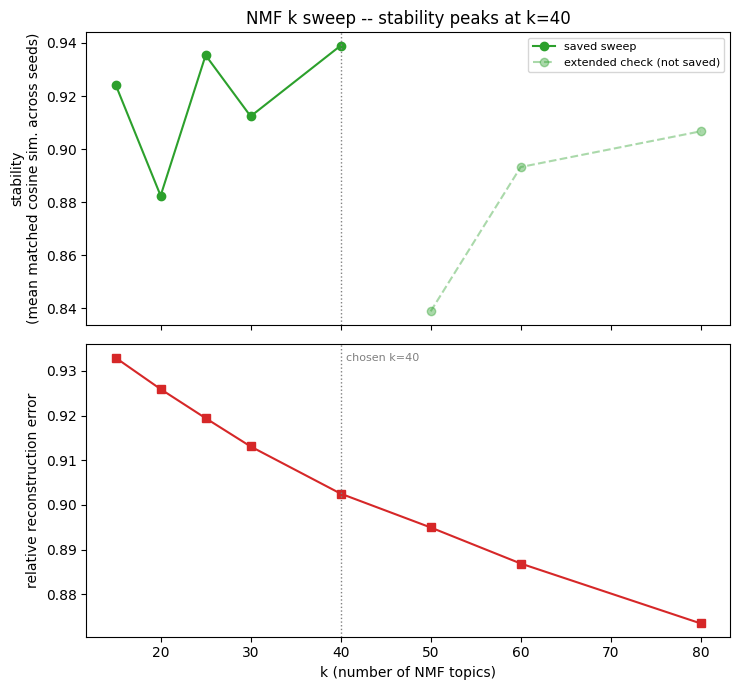

,k,reconstruction_error,stability
0,15,0.932952,0.924283
1,20,0.925924,0.882389
2,25,0.919418,0.935370
3,30,0.913080,0.912352
4,40,0.902522,0.939004
5,50,0.894948,0.838804
6,60,0.886875,0.893214
7,80,0.873459,0.906690


In [3]:
nmf_sweep_df = pd.DataFrame(nmf_manifest["sweep"])

# From the design session (docs/devlog/6.3-synergy-communities.md) -- not part of the saved
# build/manifest, see the markdown note above for why.
EXTENDED_CHECK = pd.DataFrame([
    {"k": 50, "reconstruction_error": 0.8949481391978711, "stability": 0.83880394688026},
    {"k": 60, "reconstruction_error": 0.8868750658995432, "stability": 0.8932144353687038},
    {"k": 80, "reconstruction_error": 0.8734588866434747, "stability": 0.906690264749138},
])
full_k_df = pd.concat([nmf_sweep_df, EXTENDED_CHECK], ignore_index=True).sort_values("k")
chosen_k = nmf_manifest["chosen_k"]

fig, (ax_stability, ax_error) = plt.subplots(2, 1, figsize=(7.5, 7), sharex=True)

ax_stability.plot(nmf_sweep_df["k"], nmf_sweep_df["stability"], "o-", color="tab:green", label="saved sweep")
ax_stability.plot(
    EXTENDED_CHECK["k"], EXTENDED_CHECK["stability"], "o--", color="tab:green", alpha=0.4,
    label="extended check (not saved)",
)
ax_stability.axvline(chosen_k, color="gray", linestyle=":", linewidth=1)
ax_stability.set_ylabel("stability\n(mean matched cosine sim. across seeds)")
ax_stability.set_title("NMF k sweep -- stability peaks at k=40")
ax_stability.legend(fontsize=8)

ax_error.plot(full_k_df["k"], full_k_df["reconstruction_error"], "s-", color="tab:red")
ax_error.axvline(chosen_k, color="gray", linestyle=":", linewidth=1)
ax_error.set_xlabel("k (number of NMF topics)")
ax_error.set_ylabel("relative reconstruction error")
ax_error.annotate(f"chosen k={chosen_k}", xy=(chosen_k, ax_error.get_ylim()[1]), xytext=(4, -12),
                   textcoords="offset points", fontsize=8, color="gray")

fig.tight_layout()
plt.show()

full_k_df

**NMF fit cost, for context** (measured live, single fit, no stability re-fits): k=15 -> 3.3s,
k=50 -> 32.7s, k=100 -> 191.2s, k=200 -> 733.2s. Cost grows roughly as k^2.25 -- far worse than
linear -- so a single fit at k=500 would take an estimated 1.5-2 hours, and `sweep_k`'s 4 fits
per k (1 primary + 3 stability) would make a full stability-checked sweep from k=10 to 500 take
on the order of a week of compute. Not attempted for that reason.

## Overlap check

Does the soft-membership mechanism actually deliver overlap in general? Counts how many topics
each card meaningfully belongs to (`MIN_MEMBERSHIP_SHARE=0.10` -- a real, tunable hyperparameter
in `nmf_packages.py`, along with `MAX_TOPICS_PER_CARD=5`; this excludes near-zero noise, not
genuine minor membership).

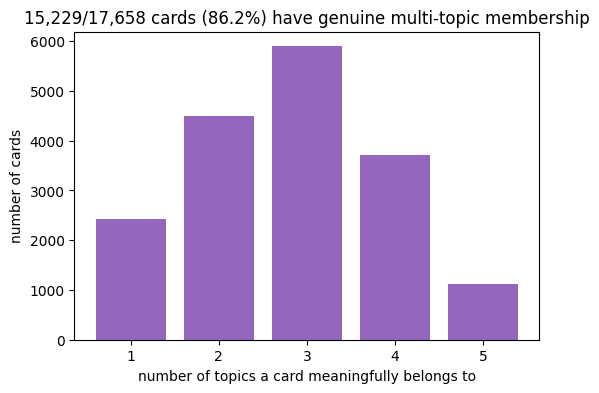

In [4]:
topic_counts = memberships.groupby("oracle_id").size()
multi = int((topic_counts > 1).sum())
counts_dist = topic_counts.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts_dist.index, counts_dist.values, color="tab:purple")
ax.set_xlabel("number of topics a card meaningfully belongs to")
ax.set_ylabel("number of cards")
ax.set_title(
    f"{multi:,}/{len(topic_counts):,} cards ({multi / len(topic_counts):.1%}) "
    f"have genuine multi-topic membership"
)
plt.show()

## All topics — quick list

One line per topic: size, an informal label (its top-3 members by EDHREC rank, just for
scanning -- topics are otherwise unnamed), and a Scryfall link (`order=edhrec`, capped to
1800 characters, sorted by EDHREC rank -- see the caveat above about what a capped
link can and can't hold).

In [5]:
topic_sorted = {
    tid: memberships_ranked[memberships_ranked["topic_id"] == tid].sort_values(
        ["edhrec_rank", "name"], na_position="last"
    )
    for tid in sorted(memberships_ranked["topic_id"].unique())
}

for tid, topic_df in topic_sorted.items():
    label = ", ".join(topic_df["name"].head(3))
    print(f"Topic {tid:2d} ({len(topic_df):,} cards) -- {label}, ...")
    print(f"  {topic_scryfall_url(topic_df)}")

Topic  0 (603 cards) -- Sol Ring, Arcane Signet, Commander's Sphere, ...
  https://scryfall.com/search?q=s%3Amsc+cn%3A211+or+s%3Amsc+cn%3A191+or+s%3Aecc+cn%3A139+or+s%3Amsc+cn%3A209+or+s%3Atla+cn%3A255+or+s%3Amoc+cn%3A372+or+s%3Afdn+cn%3A154+or+s%3Adsc+cn%3A121+or+s%3Aotc+cn%3A256+or+s%3Afdn+cn%3A505+or+s%3Admr+cn%3A69+or+s%3Amh3+cn%3A211+or+s%3Aaer+cn%3A152+or+s%3Afdn+cn%3A187+or+s%3Ablc+cn%3A14+or+s%3Akhm+cn%3A46+or+s%3Afin+cn%3A41+or+s%3Adom+cn%3A55+or+s%3Atla+cn%3A8+or+s%3Aclb+cn%3A327+or+s%3Atla+cn%3A145+or+s%3Asoc+cn%3A200+or+s%3Altr+cn%3A248+or+s%3Atla+cn%3A7+or+s%3Aspm+cn%3A25+or+s%3Amkm+cn%3A212+or+s%3Atla+cn%3A80+or+s%3Atla+cn%3A195+or+s%3Aotc+cn%3A111+or+s%3Ablb+cn%3A245+or+s%3Amic+cn%3A81+or+s%3Awoe+cn%3A247+or+s%3Afin+cn%3A48+or+s%3Adsk+cn%3A184+or+s%3Amid+cn%3A215+or+s%3Ablc+cn%3A356+or+s%3Adsk+cn%3A43+or+s%3Acmr+cn%3A298+or+s%3Aclb+cn%3A682+or+s%3Am19+cn%3A74+or+s%3Amid+cn%3A252+or+s%3Atla+cn%3A138+or+s%3Awoe+cn%3A187+or+s%3Ac20+cn%3A74+or+s%3Ablb+cn%3A209+or+s%3Aotj+cn%

  https://scryfall.com/search?q=s%3Amsc+cn%3A168+or+s%3Amsc+cn%3A217+or+s%3Afdn+cn%3A721+or+s%3Acmm+cn%3A24+or+s%3Atdc+cn%3A132+or+s%3Acmm+cn%3A413+or+s%3Altr+cn%3A245+or+s%3Atdc+cn%3A314+or+s%3Acmm+cn%3A385+or+s%3Afdn+cn%3A669+or+s%3Adsk+cn%3A161+or+s%3Athb+cn%3A236+or+s%3Amsc+cn%3A225+or+s%3Admc+cn%3A178+or+s%3Amsc+cn%3A200+or+s%3Asoc+cn%3A176+or+s%3Amsc+cn%3A130+or+s%3Alcc+cn%3A220+or+s%3Acmr+cn%3A305+or+s%3Aclb+cn%3A702+or+s%3A2xm+cn%3A296+or+s%3Aacr+cn%3A71+or+s%3Admc+cn%3A8+or+s%3Akhm+cn%3A153+or+s%3Amsc+cn%3A125+or+s%3Acmm+cn%3A51+or+s%3Acmm+cn%3A9+or+s%3Altr+cn%3A26+or+s%3Amoc+cn%3A193+or+s%3Acmr+cn%3A34+or+s%3Aotc+cn%3A269+or+s%3Aons+cn%3A185+or+s%3Asoc+cn%3A136+or+s%3Acmr+cn%3A56+or+s%3Acmm+cn%3A388+or+s%3Acmm+cn%3A375+or+s%3Adsc+cn%3A161+or+s%3Acmm+cn%3A20+or+s%3Altr+cn%3A15+or+s%3Amsc+cn%3A146+or+s%3A2x2+cn%3A156+or+s%3Afdn+cn%3A651+or+s%3Aneo+cn%3A199+or+s%3Acmr+cn%3A384+or+s%3Am21+cn%3A143+or+s%3Aafc+cn%3A202+or+s%3Aplst+cn%3AWOC-28+or+s%3Anec+cn%3A113+or+s%3Amh2+cn%3A238

  https://scryfall.com/search?q=s%3Ambc+cn%3A74+or+s%3Ambc+cn%3A76+or+s%3Aecc+cn%3A139+or+s%3Ambc+cn%3A73+or+s%3Ahoc+cn%3A211+or+s%3Amsc+cn%3A217+or+s%3Atdc+cn%3A320+or+s%3Atdc+cn%3A314+or+s%3Amh2+cn%3A228+or+s%3Aclb+cn%3A305+or+s%3Aclb+cn%3A313+or+s%3Aclb+cn%3A337+or+s%3Amsc+cn%3A142+or+s%3Aclb+cn%3A320+or+s%3Aotc+cn%3A264+or+s%3Aecc+cn%3A82+or+s%3A2x2+cn%3A301+or+s%3Amsc+cn%3A187+or+s%3Amsc+cn%3A197+or+s%3Abrc+cn%3A16+or+s%3Amoc+cn%3A11+or+s%3Aema+cn%3A60+or+s%3Amh3+cn%3A211+or+s%3Ancc+cn%3A87+or+s%3Amkc+cn%3A77+or+s%3Altr+cn%3A224+or+s%3Asnc+cn%3A105+or+s%3Admc+cn%3A180+or+s%3Asoc+cn%3A169+or+s%3Amsc+cn%3A179+or+s%3Afin+cn%3A254+or+s%3Asoc+cn%3A156+or+s%3Ac13+cn%3A47+or+s%3Awoe+cn%3A248+or+s%3Aecc+cn%3A125+or+s%3Asoc+cn%3A254+or+s%3Aclb+cn%3A299+or+s%3Acmm+cn%3A383+or+s%3Amoc+cn%3A199+or+s%3Adsk+cn%3A39+or+s%3Aacr+cn%3A17+or+s%3Asoc+cn%3A240+or+s%3Aima+cn%3A229+or+s%3Amkm+cn%3A36+or+s%3Atla+cn%3A176+or+s%3Admc+cn%3A159+or+s%3Atla+cn%3A103+or+s%3Adsc+cn%3A25+or+s%3Asoc+cn%3A141+or+s%

  https://scryfall.com/search?q=s%3Asoc+cn%3A146+or+s%3Asoc+cn%3A178+or+s%3Asoc+cn%3A153+or+s%3Asoc+cn%3A176+or+s%3Amh3+cn%3A294+or+s%3Arvr+cn%3A9+or+s%3Asoc+cn%3A142+or+s%3Acmm+cn%3A9+or+s%3Acmr+cn%3A34+or+s%3Adsc+cn%3A104+or+s%3Acmr+cn%3A56+or+s%3Ainr+cn%3A69+or+s%3Awar+cn%3A94+or+s%3Adsc+cn%3A68+or+s%3Acmm+cn%3A20+or+s%3Asoc+cn%3A316+or+s%3A2x2+cn%3A156+or+s%3Acmr+cn%3A384+or+s%3Anec+cn%3A113+or+s%3Amsc+cn%3A142+or+s%3Amkc+cn%3A92+or+s%3Adsk+cn%3A7+or+s%3Aclb+cn%3A320+or+s%3Acmm+cn%3A823+or+s%3Amsc+cn%3A139+or+s%3Asoc+cn%3A166+or+s%3Adsc+cn%3A120+or+s%3Asoc+cn%3A177+or+s%3Asoc+cn%3A137+or+s%3Asoc+cn%3A310+or+s%3Atle+cn%3A153+or+s%3Asoc+cn%3A171+or+s%3Adsc+cn%3A103+or+s%3Aafc+cn%3A8+or+s%3Apip+cn%3A14+or+s%3Atsr+cn%3A35+or+s%3Adsc+cn%3A101+or+s%3Asoc+cn%3A131+or+s%3Aafr+cn%3A23+or+s%3Asoc+cn%3A185+or+s%3Adsc+cn%3A107+or+s%3Amkc+cn%3A84+or+s%3Asoc+cn%3A175+or+s%3Asoc+cn%3A212+or+s%3Asoc+cn%3A140+or+s%3Asoc+cn%3A165+or+s%3Asoc+cn%3A298+or+s%3Abro+cn%3A14+or+s%3Adsc+cn%3A69+or+s%3Amsc+c

## Every topic — top 10 + bottom 5 by EDHREC rank

Full per-topic tables aren't practical here (topics run 470-2,254 cards, see the quick list
above) -- instead, each topic's **10 most-played** and **5 least-played** members by
`cards.edhrec_rank` (unranked cards sort last, so "least-played" among the *ranked* members).

In [6]:
for tid, topic_df in topic_sorted.items():
    print(f"### Topic {tid} -- {len(topic_df):,} cards")
    print(topic_scryfall_url(topic_df))
    print("Top 10 (most played):")
    display(topic_df[["name", "edhrec_rank", "share"]].head(10).reset_index(drop=True))
    print("Bottom 5 (least played):")
    display(topic_df[["name", "edhrec_rank", "share"]].tail(5).reset_index(drop=True))

### Topic 0 -- 603 cards
https://scryfall.com/search?q=s%3Amsc+cn%3A211+or+s%3Amsc+cn%3A191+or+s%3Aecc+cn%3A139+or+s%3Amsc+cn%3A209+or+s%3Atla+cn%3A255+or+s%3Amoc+cn%3A372+or+s%3Afdn+cn%3A154+or+s%3Adsc+cn%3A121+or+s%3Aotc+cn%3A256+or+s%3Afdn+cn%3A505+or+s%3Admr+cn%3A69+or+s%3Amh3+cn%3A211+or+s%3Aaer+cn%3A152+or+s%3Afdn+cn%3A187+or+s%3Ablc+cn%3A14+or+s%3Akhm+cn%3A46+or+s%3Afin+cn%3A41+or+s%3Adom+cn%3A55+or+s%3Atla+cn%3A8+or+s%3Aclb+cn%3A327+or+s%3Atla+cn%3A145+or+s%3Asoc+cn%3A200+or+s%3Altr+cn%3A248+or+s%3Atla+cn%3A7+or+s%3Aspm+cn%3A25+or+s%3Amkm+cn%3A212+or+s%3Atla+cn%3A80+or+s%3Atla+cn%3A195+or+s%3Aotc+cn%3A111+or+s%3Ablb+cn%3A245+or+s%3Amic+cn%3A81+or+s%3Awoe+cn%3A247+or+s%3Afin+cn%3A48+or+s%3Adsk+cn%3A184+or+s%3Amid+cn%3A215+or+s%3Ablc+cn%3A356+or+s%3Adsk+cn%3A43+or+s%3Acmr+cn%3A298+or+s%3Aclb+cn%3A682+or+s%3Am19+cn%3A74+or+s%3Amid+cn%3A252+or+s%3Atla+cn%3A138+or+s%3Awoe+cn%3A187+or+s%3Ac20+cn%3A74+or+s%3Ablb+cn%3A209+or+s%3Aotj+cn%3A66+or+s%3Amkm+cn%3A64+or+s%3Atla+cn%3A141+or+s%3

,name,edhrec_rank,share
0,Sol Ring,1.0,0.465108
1,Arcane Signet,3.0,0.910501
2,Commander's Sphere,50.0,0.305560
3,Relic of Legends,546.0,0.144302
4,Bender's Waterskin,620.0,0.203133
5,Replicating Ring,1574.0,0.166982
6,Extravagant Replication,1765.0,0.112033
7,One with the Multiverse,1912.0,0.102396
8,Darksteel Ingot,2000.0,0.168948
9,Cancel,2041.0,0.292043


Bottom 5 (least played):


,name,edhrec_rank,share
0,Tears of Valakut,26866.0,0.190591
1,Byway Courier,26964.0,1.000000
2,Ritual Guardian,27164.0,0.376437
3,Faithbearer Paladin,27249.0,0.376437
4,Boreal Elemental,28869.0,0.390698


### Topic 1 -- 2,214 cards
https://scryfall.com/search?q=s%3Amsc+cn%3A172+or+s%3Amsc+cn%3A173+or+s%3Amsc+cn%3A169+or+s%3Atdc+cn%3A265+or+s%3Aecc+cn%3A113+or+s%3Ambc+cn%3A73+or+s%3Asoc+cn%3A285+or+s%3Aecc+cn%3A115+or+s%3Adsc+cn%3A88+or+s%3Atle+cn%3A259+or+s%3Aeoc+cn%3A98+or+s%3Aecc+cn%3A98+or+s%3Aeoc+cn%3A107+or+s%3Amsc+cn%3A175+or+s%3Aecc+cn%3A131+or+s%3Aeoc+cn%3A104+or+s%3Ancc+cn%3A311+or+s%3Altr+cn%3A163+or+s%3Atdm+cn%3A159+or+s%3Ainr+cn%3A223+or+s%3Afdn+cn%3A247+or+s%3Amkc+cn%3A241+or+s%3Aecc+cn%3A53+or+s%3Amsc+cn%3A178+or+s%3Adsc+cn%3A252+or+s%3Ac21+cn%3A198+or+s%3Adsc+cn%3A246+or+s%3Aema+cn%3A167+or+s%3Acmm+cn%3A928+or+s%3Amoc+cn%3A309+or+s%3Aclu+cn%3A223+or+s%3Adsc+cn%3A210+or+s%3Adsc+cn%3A205+or+s%3Aotc+cn%3A220+or+s%3Atdc+cn%3A244+or+s%3Afdn+cn%3A161+or+s%3Acmm+cn%3A296+or+s%3Atdc+cn%3A324+or+s%3Amh1+cn%3A180+or+s%3Atdc+cn%3A262+or+s%3Adsc+cn%3A178+or+s%3Ac13+cn%3A162+or+s%3Atla+cn%3A196+or+s%3Adsc+cn%3A177+or+s%3Adsc+cn%3A169+or+s%3Afdn+cn%3A215+or+s%3Arvr+cn%3A172+or+s%3Aclu+

...

,name,edhrec_rank,share
0,Yotian Medic,25303.0,0.131698
1,"Colossus, Steel Stalwart",25404.0,0.120255
2,Titan's Revenge,26131.0,0.108404
3,Volcanic Villain,26313.0,0.108377
4,Heat Wave,27357.0,0.252157


### Topic 39 -- 1,109 cards
https://scryfall.com/search?q=s%3Adsc+cn%3A114+or+s%3Afdn+cn%3A160+or+s%3Amsc+cn%3A147+or+s%3Atmt+cn%3A47+or+s%3Aeoc+cn%3A46+or+s%3Amsc+cn%3A151+or+s%3Atdc+cn%3A160+or+s%3Asoc+cn%3A198+or+s%3Adsc+cn%3A88+or+s%3Awar+cn%3A193+or+s%3Ainr+cn%3A68+or+s%3Asoc+cn%3A199+or+s%3Afdn+cn%3A151+or+s%3Alcc+cn%3A146+or+s%3Afdn+cn%3A247+or+s%3Aclu+cn%3A211+or+s%3Adsc+cn%3A252+or+s%3Arvr+cn%3A50+or+s%3Acmr+cn%3A56+or+s%3Ainr+cn%3A69+or+s%3Adsk+cn%3A51+or+s%3Atdc+cn%3A170+or+s%3Asoc+cn%3A192+or+s%3Aeoc+cn%3A80+or+s%3Adsc+cn%3A210+or+s%3Amsc+cn%3A153+or+s%3Asoc+cn%3A202+or+s%3Abfz+cn%3A76+or+s%3Adft+cn%3A64+or+s%3Aeoc+cn%3A77+or+s%3Amh3+cn%3A71+or+s%3Amm2+cn%3A49+or+s%3Alcc+cn%3A158+or+s%3Aclu+cn%3A99+or+s%3Amh3+cn%3A59+or+s%3Amh3+cn%3A51+or+s%3Alcc+cn%3A288+or+s%3Acmm+cn%3A847+or+s%3Amkc+cn%3A198+or+s%3Amkc+cn%3A213+or+s%3Adft+cn%3A67+or+s%3Ablb+cn%3A58+or+s%3Amh3+cn%3A198+or+s%3Atle+cn%3A156+or+s%3Atmc+cn%3A46+or+s%3Aktk+cn%3A56+or+s%3Alci+cn%3A63+or+s%3Alcc+cn%3A273+or+s%3A

,name,edhrec_rank,share
0,Counterspell,16.0,0.846750
1,An Offer You Can't Refuse,35.0,0.463928
2,Arcane Denial,54.0,0.507719
3,Negate,55.0,0.845421
4,Swan Song,70.0,0.159587
5,Propaganda,115.0,0.205213
6,Pongify,154.0,0.255656
7,Rapid Hybridization,208.0,0.263665
8,Growth Spiral,230.0,0.252297
9,Dovin's Veto,241.0,0.283875


Bottom 5 (least played):


,name,edhrec_rank,share
0,Brave Brawler,25815.0,0.102597
1,Giant Octopus,26675.0,0.383795
2,Minamo Scrollkeeper,27020.0,0.643707
3,War Oracle,28575.0,0.490559
4,Boreal Elemental,28869.0,0.353575


## Named example: Ashnod's Altar

The plan's own motivating example for why hard clustering wasn't enough: Ashnod's Altar is a
sac outlet *and* a combo piece. Its own topic membership below, plus each topic it lands in.

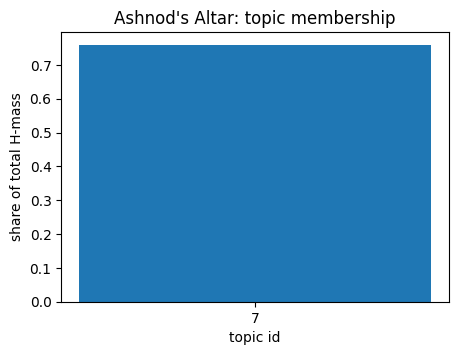

Ashnod's Altar's share of topic 7: 75.9% (1,658 cards)
https://scryfall.com/search?q=s%3Amsc+cn%3A215+or+s%3Amsc+cn%3A210+or+s%3Amsc+cn%3A161+or+s%3Atle+cn%3A257+or+s%3Asoc+cn%3A285+or+s%3Asoc+cn%3A294+or+s%3Atdc+cn%3A198+or+s%3Amsc+cn%3A794+or+s%3Acmm+cn%3A368+or+s%3Asoc+cn%3A209+or+s%3Ainr+cn%3A137+or+s%3Alcc+cn%3A208+or+s%3Altr+cn%3A95+or+s%3Adsc+cn%3A197+or+s%3Asoc+cn%3A233+or+s%3Adsc+cn%3A142+or+s%3Asoc+cn%3A219+or+s%3Asoc+cn%3A229+or+s%3Adsc+cn%3A158+or+s%3Altr+cn%3A103+or+s%3Awar+cn%3A79+or+s%3Abro+cn%3A89+or+s%3Amh3+cn%3A292+or+s%3Aeoc+cn%3A82+or+s%3Asoc+cn%3A178+or+s%3A2x2+cn%3A311+or+s%3Atle+cn%3A160+or+s%3Amh3+cn%3A110+or+s%3Aone+cn%3A23+or+s%3Amh2+cn%3A279+or+s%3Atdc+cn%3A185+or+s%3Amh3+cn%3A80+or+s%3Ainr+cn%3A122+or+s%3Afdn+cn%3A754+or+s%3Afdn+cn%3A183+or+s%3Afdn+cn%3A57+or+s%3Arvr+cn%3A70+or+s%3Acmm+cn%3A153+or+s%3Aexo+cn%3A55+or+s%3Amh3+cn%3A100+or+s%3Acmm+cn%3A165+or+s%3Asoc+cn%3A302+or+s%3Aeoc+cn%3A121+or+s%3Aunf+cn%3A88+or+s%3Aotj+cn%3A84+or+s%3Asoc+cn%3A167+or+s%3Adm

,name,edhrec_rank,share
0,Solemn Simulacrum,38.0,0.200940
1,Skullclamp,40.0,0.552902
2,Toxic Deluge,67.0,0.150063
3,Feed the Swarm,89.0,0.111067
4,Sakura-Tribe Elder,110.0,0.167264
5,Assassin's Trophy,122.0,0.124480
6,Victimize,128.0,0.484053
7,Deadly Dispute,129.0,0.642930
8,Ashnod's Altar,132.0,0.758890
9,Blood Artist,138.0,0.820937


In [7]:
target = "Ashnod's Altar"
oracle_id = resolve_oracle_id(target)
topics = card_topics(memberships, oracle_id)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(topics["topic_id"].astype(str), topics["share"], color="tab:blue")
ax.set_xlabel("topic id")
ax.set_ylabel("share of total H-mass")
ax.set_title(f"{target}: topic membership")
plt.show()

for _, row in topics.iterrows():
    tid = int(row["topic_id"])
    topic_df = topic_sorted[tid]
    print(f"{target}'s share of topic {tid}: {row['share']:.1%} ({len(topic_df):,} cards)")
    print(topic_scryfall_url(topic_df))
    display(topic_df[["name", "edhrec_rank", "share"]].head(10).reset_index(drop=True))

# Task 6.3-B: color bias, granularity, and Girvan-Newman

The sections above are the original task 6.3 exploration (flat NMF only). Everything below is
task 6.3-B's follow-up (plan `docs/plans/6.3b-communities-next-iteration.md`), answering three
questions raised on review of the above: can the color-identity fix be used with NMF; can we get
more, narrower communities; and is the Girvan-Newman algorithm from class relevant here. All
artifacts are pre-built and loaded, not rebuilt in this notebook -- rebuild with
`python -m edhcut.analysis.symnmf_packages build` then `python -m edhcut.analysis.symnmf_hierarchy
build` (and `... curve` for the granularity sweep) if the underlying data has changed.

In [ ]:
import numpy as np

from edhcut.analysis import symnmf_packages
from edhcut.analysis.symnmf_hierarchy import load_hierarchy
from edhcut.analysis.theme_labels import build_theme_labels, color_purity, granularity_report, topic_theme_enrichment

symnmf_memberships = symnmf_packages.load_card_memberships(KB_DEV_DIR)
symnmf_manifest = json.loads((KB_DEV_DIR / "symnmf_manifest.json").read_text())

print(
    f"SymNMF: chosen k={symnmf_manifest['chosen_k']} "
    f"(stability={symnmf_manifest['chosen_stability']:.3f}, "
    f"relative_residual={symnmf_manifest['chosen_relative_residual']:.3f}, "
    f"fit={symnmf_manifest['chosen_fit_seconds']:.1f}s)."
)
print(
    f"{symnmf_manifest['n_cards_in_pool']:,} cards in the SymNMF pool "
    f"({symnmf_manifest['n_basic_lands_excluded']} basic lands excluded, top-"
    f"{symnmf_manifest['top_k']} union-sparsified, zero-degree dropped)."
)
print("k sweep (wider grid than flat NMF's -- fits are far cheaper, see the devlog):")
for r in symnmf_manifest["sweep"]:
    marker = " <-- chosen" if r["k"] == symnmf_manifest["chosen_k"] else ""
    print(f"  k={r['k']:3d}  stability={r['stability']:.3f}  "
          f"relative_residual={r['relative_residual']:.3f}  fit={r['fit_seconds']:6.1f}s{marker}")

## Q1: color bias, before/after

**The plan's hypothesis**: NMF can't take the color-legality fix directly (a card's color
identity is *structural* in the deck×card matrix -- no column rescaling removes it), but
switching the factorization to symmetric NMF (`S ≈ HHᵀ`) over the already color-corrected
`compute_color_conditioned_tscore` matrix should. Per-topic color purity = share of a topic's
top-30 members (by weight) carrying the topic's own single most common color identity.

In [ ]:
nmf_purity, null_draws = color_purity(memberships, conn, n_null_draws=2000, seed=0)
symnmf_purity, _ = color_purity(symnmf_memberships, conn, n_null_draws=2000, seed=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, 1, 21)
ax.hist(null_draws, bins=bins, alpha=0.5, density=True, label="random null (2,000 draws)", color="gray")
ax.hist(nmf_purity["purity"], bins=bins, alpha=0.6, density=True, label="flat NMF (k=40)", color="tab:orange")
ax.hist(symnmf_purity["purity"], bins=bins, alpha=0.6, density=True, label="SymNMF (color-corrected)", color="tab:blue")
ax.set_xlabel("topic color purity (top-30 members, modal color-identity share)")
ax.set_ylabel("density")
ax.set_title("Color purity: random null vs. flat NMF vs. color-corrected SymNMF")
ax.legend(fontsize=9)
plt.show()

print(f"median purity -- null: {np.median(null_draws):.1%}  "
      f"NMF: {nmf_purity['purity'].median():.1%}  SymNMF: {symnmf_purity['purity'].median():.1%}")
print(f"topics >=90% purity -- NMF: {(nmf_purity['purity'] >= 0.9).sum()}/{len(nmf_purity)}  "
      f"SymNMF: {(symnmf_purity['purity'] >= 0.9).sum()}/{len(symnmf_purity)}")
print(f"topics at exactly 100% purity -- NMF: {(nmf_purity['purity'] >= 0.999).sum()}  "
      f"SymNMF: {(symnmf_purity['purity'] >= 0.999).sum()}")

**Honest result: topic-level purity barely moved (median ~67% either way), even though the
correction demonstrably works at the edge level.** Measured directly (not shown in this
notebook, see the devlog): sampling 500 cards' top-50 color-conditioned-t-score neighbors vs.
their top-50 *pooled* (uncorrected) t-score neighbors, mean same-color-identity share drops from
48.3% to 44.7% -- a real, if modest, effect, consistent with the correction's own validated
20-pair check (`docs/devlog/6.1-cooccurrence.md`). But that edge-level shift doesn't propagate
into a comparable topic-level change. The best current explanation: a large share of what looked
like "color bias" in the flat NMF build was never a legality artifact to begin with -- it's
genuine archetype structure (Goblins really is a red archetype), which no correction to the
*co-occurrence null model* can or should remove. This is a real answer to the open question left
at the end of the original 6.3 devlog ("is this bias or genuine synergy"), just not the clean
"yes, fixed" the plan hoped for.

## Theme enrichment table

Replaces the earlier "top-3 members by EDHREC rank" informal topic labels with real statistics:
for each SymNMF topic, its top-3 `card_tags`/`edhrec_themes`-derived labels by enrichment lift
(hypergeometric test, BH-FDR corrected across the whole grid -- see `theme_labels.py`), plus
each label's `resolution` (`min(share_of_topic, recall_of_label)` -- the granularity metric this
whole step exists to move, see the next section).

In [ ]:
symnmf_pool = set(symnmf_memberships["oracle_id"])
symnmf_labels = build_theme_labels(conn, pool_oracle_ids=symnmf_pool)
symnmf_enrichment = topic_theme_enrichment(symnmf_memberships, symnmf_labels)

symnmf_gran = granularity_report(symnmf_memberships, symnmf_labels)
print(f"Label vocabulary: {symnmf_gran['vocab_size']} tags across {symnmf_gran['n_topics']} topics.")
print(f"  covered (enriched in >=1 topic): {symnmf_gran['n_labels_covered']} / {symnmf_gran['vocab_size']}")
for tau, n in symnmf_gran["n_labels_resolved"].items():
    print(f"  resolved at tau={tau}: {n} / {symnmf_gran['vocab_size']}")
print(f"  median distinct labels per topic: {symnmf_gran['median_labels_per_topic']:.1f}")

print("\nTop-3 enriched labels per topic (by lift):")
for tid in sorted(symnmf_memberships["topic_id"].unique()):
    top3 = symnmf_enrichment[symnmf_enrichment["topic_id"] == tid].sort_values("lift", ascending=False).head(3)
    if top3.empty:
        print(f"Topic {tid:2d}: (no significantly enriched labels)")
        continue
    label_str = ", ".join(f"{row['label']} (lift {row['lift']:.1f}x, res={row['resolution']:.0%})"
                           for _, row in top3.iterrows())
    print(f"Topic {tid:2d}: {label_str}")

## Q2: granularity via hierarchical decomposition

The plan's answer to "40 topics isn't granular enough": don't chase it with a wider flat `k` --
recurse (`edhcut/analysis/symnmf_hierarchy.py`). Fit a small top-level split, then for each
topic induce the color-conditioned matrix on just its own members and split again, recursively.
The two curves below (`python -m edhcut.analysis.symnmf_hierarchy curve`, cached to
`symnmf_hierarchy_granularity_curve.parquet`) are what turn "how many communities" from a feeling
into a decision: resolved-label count and median color purity, both vs. the number of leaves the
tree is cut to.

**The plan's own originally-stated ceiling (~400 leaves) turned out to be conservative** --
resolved-label count was still climbing there. Extending the sweep live found the real shape:
resolved-count peaks around 1,200 leaves (356/985) before gently declining at extreme
fragmentation, while median labels-per-topic keeps falling throughout. **Both of the plan's
pre-declared targets are met, but not at the same point**: resolved-count clears >=250 by
~n_leaves=250 and stays well clear of it the whole way; median labels-per-topic only reaches
<=6 around n_leaves≈1,700-2,000 (crossing exactly at 1,700: 6.0), close to the full tree
(1,988 of 2,020 total leaves). Both hold simultaneously from ~1,700 leaves on -- comfortably
inside budget once the sweep was actually extended, and without needing step 4's anchored/
semi-supervised extension at all (its own trigger condition -- the curve saturating below
target -- never happened).

**A real bug was caught and fixed while building this section, worth flagging explicitly**: an
earlier version of `cut_at` renormalized a card's `share` by summing its `weight` across every
node it appears in within a cut -- but weights from *different* nodes come from *different*
local SymNMF fits (different induced submatrices, no shared scale), so that sum wasn't a
meaningful quantity. A card that legitimately clears its own membership threshold in many
different branches (Cultivate: 44 of 1,200 nodes in one real cut) had every one of those real
memberships diluted below threshold simultaneously by the sum, and dropped from the cut's output
entirely -- caught by trying to look up a specific named example and getting zero rows back, not
by a passing test (the toy fixtures were too small to trigger 40+-way fan-out). Fixed by keeping
each node's own already-meaningful `share` and capping fan-out to the strongest few nodes
instead of renormalizing across incommensurable ones -- see `symnmf_hierarchy.cut_at`'s own
docstring.

In [ ]:
curve = pd.read_parquet(KB_DEV_DIR / "symnmf_hierarchy_granularity_curve.parquet")
CHOSEN_N_LEAVES = 1200  # near-peak resolved-count; the median-labels-per-topic target needs a
                        # deeper cut (~1,700+, see markdown above) -- marked on both panels below

fig, (ax_resolved, ax_purity) = plt.subplots(2, 1, figsize=(7.5, 7), sharex=True)

ax_resolved.plot(curve["actual_leaves"], curve["n_labels_resolved_010"], "o-", color="tab:green")
ax_resolved.axhline(250, color="gray", linestyle=":", linewidth=1, label="plan target (>=250)")
ax_resolved.axvline(CHOSEN_N_LEAVES, color="gray", linestyle="--", linewidth=1)
ax_resolved.set_ylabel("labels resolved\n(tau=0.10)")
ax_resolved.set_title("Granularity: resolved-label count vs. tree cut size")
ax_resolved.legend(fontsize=8, loc="lower right")

ax_labels_per_topic = ax_resolved.twinx()
ax_labels_per_topic.plot(curve["actual_leaves"], curve["median_labels_per_topic"], "s--", color="tab:red", alpha=0.7)
ax_labels_per_topic.axhline(6, color="tab:red", linestyle=":", linewidth=1, alpha=0.5)
ax_labels_per_topic.set_ylabel("median labels/topic\n(bundling, dashed)", color="tab:red")

ax_purity.plot(curve["actual_leaves"], curve["median_purity"], "o-", color="tab:blue")
ax_purity.axhline(0.667, color="tab:orange", linestyle=":", linewidth=1, label="flat NMF median (66.7%)")
ax_purity.axvline(CHOSEN_N_LEAVES, color="gray", linestyle="--", linewidth=1)
ax_purity.set_xlabel("number of leaves in the cut")
ax_purity.set_ylabel("median color purity")
ax_purity.legend(fontsize=8)

fig.tight_layout()
plt.show()

curve[["requested_leaves", "actual_leaves", "n_labels_resolved_010", "median_labels_per_topic", "median_purity"]]

**Named example at the finer cut**: Cultivate sat in one 1,470-card "green" topic in the flat
NMF build. At the chosen `n_leaves=1200` hierarchy cut, it should land in a much smaller,
narrower ramp-specific node.

In [ ]:
nodes = load_hierarchy()
from edhcut.analysis.symnmf_hierarchy import cut_at

hierarchy_cut = cut_at(nodes, CHOSEN_N_LEAVES)
hierarchy_cut_ranked = hierarchy_cut.merge(card_ranks, on="oracle_id", how="left")

for target in ["Cultivate", "Ashnod's Altar"]:
    oid = resolve_oracle_id(target)
    rows = hierarchy_cut_ranked[hierarchy_cut_ranked["oracle_id"] == oid].sort_values("share", ascending=False)
    print(f"\n{target}: {len(rows)} node membership(s) at n_leaves={CHOSEN_N_LEAVES}")
    for _, row in rows.iterrows():
        node_df = hierarchy_cut_ranked[hierarchy_cut_ranked["topic_id"] == row["topic_id"]].sort_values(
            ["edhrec_rank", "name"], na_position="last"
        )
        top5 = ", ".join(node_df["name"].head(5))
        print(f"  node {int(row['topic_id']):4d}  share={row['share']:.1%}  "
              f"({len(node_df)} cards) -- {top5}")

## Q3: is Girvan-Newman relevant?

**Not globally -- the arithmetic, on this project's own graph, not a generic estimate.** This
notebook's SymNMF input graph (`symnmf_S.npz`, top-50 union-sparsified) has `n=18,292` nodes and
`m≈568,820` undirected edges. A single edge-betweenness computation is `O(nm) ≈ 1.0×10^10`
operations, and Girvan-Newman recomputes it after *every* edge removal -- up to `m` removals, so
up to `m × O(nm) ≈ 5.9×10^15` operations for a full run. It's also the wrong output shape for
this project regardless of runtime: GN produces a hard, nested partition, and hard partitions are
exactly what this project moved away from (Ashnod's Altar: sac outlet *and* combo piece,
unrepresentable in one branch of a dendrogram).

**Not even at "one topic" scale, measured, not assumed.** The plan's own working assumption was
that a single topic (~300-600 cards) would make true GN cheap. Checked live instead of trusted:
running `community_edge_betweenness` on topic 9's real induced subgraph (`n=1,313`, `m=21,575`)
took **3,923 seconds (~65 minutes)** -- topics in this build run denser and larger than assumed.
The sub-section below restricts to a topic's own top-150 members by weight instead (measured:
14.2s at n=150 vs. 71.5s at n=250 vs. 237.4s at n=400 -- confirming genuinely superlinear cost,
not a fluke of one run), which is itself informative: even "just one already-identified package"
is too dense for the textbook algorithm at its natural size on this data, and *narrowing further
to the package's own core* is what it actually takes to make GN usable here.

**But the actual thing wanted -- a dendrogram you can cut manually, with modularity plotted
against cluster count -- doesn't require GN specifically.** `igraph.Graph.community_fastgreedy`
(CNM, `O(n log²n)`) returns the same `VertexDendrogram` shape and is tractable at full graph
size (measured: 40-47s -- see the second sub-section below). For the *soft* SymNMF model, the
hierarchy built in the previous section is the direct analogue, plotted against the
theme-resolution metric instead of modularity.

**One real insight fell out of asking this anyway**: modularity has a known resolution limit
(Fortunato & Barthélemy 2007) -- communities smaller than roughly `sqrt(2m)` internal edges tend
to get merged rather than detected. On this graph, `sqrt(2 x 568,820) ≈ 1,067` edges, and with
mean degree `2m/n ≈ 62` that implies a rough floor on the *smallest modularity-detectable*
package size -- consistent with why a resolution/k-sweep on a flat modularity- or reconstruction-
error-driven objective (Leiden, flat NMF/SymNMF alike) tops out well short of real per-archetype
granularity, and why this project moved to hierarchical recursion (a fundamentally different
lever) rather than continuing to push a single global objective harder.

### True Girvan-Newman, on one topic's top-150 members

Restricted to a topic's own top-150 members by weight (not the whole ~1,300-card topic -- see
the timing note above) to keep this cell actually runnable: ~14s measured, vs. ~65 minutes for
the full topic. Runs the real algorithm from class on real project data, splitting one
already-identified package's core down into its own sub-packages.

In [ ]:
import igraph as ig

S = symnmf_packages.load_S()
pool_index = symnmf_packages.load_pool_index()
oracle_to_row = dict(zip(pool_index["oracle_id"], range(len(pool_index))))

GN_TOPIC = 9  # the Ashnod's Altar sac-outlet/aristocrats topic from the flat SymNMF build
GN_TOP_N = 150  # see the markdown above -- the full topic (~1,300 cards) took ~65 minutes
topic_members_df = symnmf_memberships[symnmf_memberships["topic_id"] == GN_TOPIC].sort_values(
    "weight", ascending=False
).head(GN_TOP_N)
topic_members_df = topic_members_df[topic_members_df["oracle_id"].isin(oracle_to_row)]
local_oracle_ids = list(topic_members_df["oracle_id"])
topic_rows = [oracle_to_row[oid] for oid in local_oracle_ids]

sub_S = S[topic_rows][:, topic_rows].tocoo()
upper = sub_S.row < sub_S.col
sub_edges = list(zip(sub_S.row[upper].tolist(), sub_S.col[upper].tolist()))
sub_weights = sub_S.data[upper].tolist()

sub_graph = ig.Graph(n=len(topic_rows), edges=sub_edges)
sub_graph.es["weight"] = sub_weights
print(f"Topic {GN_TOPIC}, top {GN_TOP_N} members: n={sub_graph.vcount():,} m={sub_graph.ecount():,}")

import time
t0 = time.perf_counter()
gn_dendro = sub_graph.community_edge_betweenness(weights="weight")
t1 = time.perf_counter()
print(f"community_edge_betweenness: {t1 - t0:.1f}s")

# Sweep the full dendrogram, not a truncated prefix -- and use igraph's own `optimal_count`
# (computed once, cheaply, over the whole merge sequence) for the best cut rather than an
# argmax over an arbitrarily-capped range, which can silently pick an edge-of-range value that
# isn't actually the peak (found live: capping at 30 picked n=30 itself, still on the rising
# part of the curve).
n_range = list(range(1, len(topic_rows), max(1, len(topic_rows) // 60)))
gn_modularities = [gn_dendro.as_clustering(n).modularity for n in n_range]
best_n = gn_dendro.optimal_count

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(n_range, gn_modularities, "o-", color="tab:purple")
ax.axvline(best_n, color="gray", linestyle=":", linewidth=1, label=f"optimal_count={best_n}")
ax.set_xlabel("number of clusters (Girvan-Newman cut)")
ax.set_ylabel("modularity")
ax.set_title(f"Girvan-Newman on topic {GN_TOPIC}'s top-{GN_TOP_N} members -- modularity vs. cut")
ax.legend(fontsize=8)
plt.show()

best_clustering = gn_dendro.as_clustering(best_n)
print(f"Best cut ({best_n} clusters): modularity={best_clustering.modularity:.4f}\n")

local_df = topic_members_df[["oracle_id", "name"]].reset_index(drop=True).merge(
    card_ranks, on="oracle_id", how="left"
)
local_df["cluster"] = best_clustering.membership
cluster_sizes = local_df.groupby("cluster").size().sort_values(ascending=False)
print(f"{(cluster_sizes == 1).sum()} of {len(cluster_sizes)} sub-clusters are singletons -- see "
      f"the markdown note below for why this pattern shows up here.")
for cluster_id in cluster_sizes[cluster_sizes > 1].index:
    group = local_df[local_df["cluster"] == cluster_id].sort_values("edhrec_rank", na_position="last")
    top5 = ", ".join(group["name"].head(5))
    print(f"  sub-cluster {cluster_id} ({len(group)} cards): {top5}")

**Why the best cut is one big cluster plus many singletons, not several balanced sub-packages**:
selecting a topic's top-150 members *by weight* selects for the topic's most generically central
cards -- the ones strongly connected to nearly everything else in the topic, which is exactly
what a high SymNMF weight means. That's a homogeneity filter, not a diversity sample, so the
induced subgraph is dominated by one dense hub with a scattering of comparatively peripheral
cards hanging off it -- and Girvan-Newman's own logic (repeatedly cut the globally highest-
betweenness edge) peels those peripheral cards off one at a time before it ever finds a second
real hub to split off, because there isn't a second one in this particular 150-card slice. A
genuinely balanced multi-way split would need a sample that includes more of the topic's own
*outskirts* (lower-weight, more specialized members), not just its most confidently-central
core -- the tradeoff being that a less weight-filtered sample is denser and larger, and would
cost more of the runtime this restriction exists to avoid in the first place.

### `community_fastgreedy` on the *full* graph -- the scalable stand-in

CNM/fastgreedy on this project's own full graph (`n=18,292`, `m=568,820`) runs in well under a
minute (measured live: ~47s) -- tractable where true Girvan-Newman's ~5.9×10^15-operation
estimate above is not. It's a hard-partition method, same caveat as GN, but produces the
"dendrogram + modularity vs. cluster count" deliverable at full scale.

In [ ]:
coo = S.tocoo()
upper = coo.row < coo.col
full_edges = list(zip(coo.row[upper].tolist(), coo.col[upper].tolist()))
full_weights = coo.data[upper].tolist()

full_graph = ig.Graph(n=S.shape[0], edges=full_edges)
full_graph.es["weight"] = full_weights
print(f"Full graph: n={full_graph.vcount():,} m={full_graph.ecount():,}")

import time
t0 = time.perf_counter()
fg_dendro = full_graph.community_fastgreedy(weights="weight")
t1 = time.perf_counter()
print(f"community_fastgreedy: {t1 - t0:.1f}s")
print(f"dendrogram's own best cut (optimal_count): {fg_dendro.optimal_count} clusters")

n_range = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 30, 60, 100, 300, 1000]
fg_modularities = [fg_dendro.as_clustering(n).modularity for n in n_range]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(n_range, fg_modularities, "o-", color="tab:brown")
ax.set_xscale("log")
ax.axvline(fg_dendro.optimal_count, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("number of clusters (log scale)")
ax.set_ylabel("modularity")
ax.set_title("community_fastgreedy on the full graph -- modularity plateaus almost immediately")
plt.show()

**Measured live: modularity rises to ~0.513 by ~10-16 clusters, then goes completely flat --
even dipping slightly -- all the way out to 1,000 clusters**, while the top cluster sizes barely
move (a ~5,800-card giant component stays a ~5,300-card giant component even at a 1,000-cluster
cut). This is the resolution-limit argument from the markdown above, not asserted but directly
observed: a modularity-driven objective structurally cannot see finer structure past a coarse
handful of macro-communities on this graph, no matter how many clusters you ask the cut for --
exactly why this project moved to hierarchical *recursion* (a genuinely different mechanism,
each level solving its own local, smaller-scale objective) rather than continuing to push a
single global modularity/reconstruction-error objective for granularity.

## Task 6.3-B takeaways

- **Q1 (color bias via NMF)**: solved technically (symmetric NMF over
  `compute_color_conditioned_tscore`, no raw-presence-NMF patch needed), but the topic-level
  purity result was a genuine surprise -- median purity barely moved (66.7% -> 68.3%) despite a
  real, measured edge-level effect (48.3% -> 44.7% mean same-color-identity share among top-50
  neighbors). Best current read: most of what looked like "color bias" in the flat build was
  already genuine archetype signal, not a legality artifact -- a real (partial) answer to the
  open question left at the end of the original 6.3 devlog, not the clean fix hoped for.
- **Q2 (granularity)**: hierarchical recursion worked. Resolved-label count clears the plan's
  >=250 target early and stays clear (peaking 356/985 around n_leaves=1,200); median
  labels/topic keeps falling throughout and crosses the plan's <=6 target around n_leaves≈1,700,
  near the full 2,020-leaf tree -- both targets hold simultaneously from there on. Neither target
  needed the plan's conditional step 4 (anchored/semi-supervised SymNMF): step 3's curve never
  saturated below target, it just needed a wider sweep than the plan's own originally-stated
  ~400-leaf ceiling (revised upward live once the first sweep showed it still climbing).
- **Q3 (Girvan-Newman)**: correctly ruled out globally on cost grounds (~5.9×10^15 ops on this
  project's own graph) and shape grounds (hard partitions). The plan also assumed a *single
  topic* (~300-600 cards) would be cheap for true GN -- checked live, not trusted: topic 9's
  real induced subgraph (n=1,313, m=21,575) took **3,923 seconds (~65 minutes)**, topics here
  run denser than assumed. Restricting to a topic's own top-150 members by weight (14.2s
  measured) was what actually made the "run real GN on one package" demo usable.
  `community_fastgreedy` as the full-graph scalable stand-in surfaced a clean, directly-observed
  illustration of modularity's resolution limit (flat past ~16 clusters, all the way to 1,000)
  -- independent confirmation of *why* a flat modularity/reconstruction-error objective (Leiden,
  flat NMF, flat SymNMF alike) tops out well short of real per-archetype granularity, and why
  recursion (not a wider single-shot sweep) was the right lever for Q2.
- **Two real bugs were found and fixed along the way, both by noticing a number that didn't add
  up rather than by a failing test**: (1) `theme_labels.granularity_report`'s
  `median_labels_per_topic` silently returned 0.0 for any non-contiguous `topic_id` scheme (a
  hierarchy cut's `topic_id` is a `node_id`, not `0..k-1`) -- caught by actually looking at the
  hierarchy's own numbers. (2) `symnmf_hierarchy.cut_at` renormalized a card's `share` by
  summing `weight` across every node it appeared in within a cut, silently combining values from
  unrelated local SymNMF fits with no shared scale -- caught when a named example (Cultivate)
  came back with zero memberships at a cut where it demonstrably belonged in five. Both are
  regression-tested now; both slipped past the original toy-fixture tests because those fixtures
  were too small to trigger the failure mode (a handful of topics, not the 40+-branch fan-out a
  real 2,000+-leaf tree produces).
- Full numeric detail, the rejected NMF-patch alternatives, the SymNMF solver's derivation
  (including the `BETA=0.5` damping choice, checked live across 18 (k, seed) combinations rather
  than assumed), and the units-mismatch fix underneath the color-conditioned null model are in
  `docs/devlog/6.3b-communities-next-iteration.md`, not repeated here.

## Takeaways

- Dropping hard clustering in favor of soft-only removes duplicated confound-fixing machinery
  (near-uniform weighting vs. deck subsampling, basics-only vs. all-lands exclusion) for output
  the soft version already subsumes.
- 40 topics is coarse next to EDHREC's own ~400-tag theme/typal taxonomy (`edhrec_themes`,
  already imported) -- both Leiden and NMF's own selection criteria (modularity, stability)
  independently topped out well short of that granularity on the current corpus, which points at
  a statistical-power/corpus-depth limit rather than "40 is the true number of packages." Getting
  to EDHREC's granularity likely means leaning on `edhrec_themes`/`card_tags` as a supervision
  signal rather than pushing unsupervised k/resolution harder -- worth deciding deliberately
  before spending the (very real, k^2.25-scaling) compute on a wider sweep.
- Scryfall links use `s:<set_code> cn:<collector_number>` (`cards.set_code`/
  `cards.collector_number`, backfilled from the already-ingested Scryfall bulk data), the
  shortest reliable per-card query -- shorter than both `name:"..."` and `oracleid:<uuid>`.